# Kidney injury analysis

This tutorial analyzes a multisample Xenium kidney injury experiment with three control kidneys and three kidneys collected after ischemia-reperfusion injury (IRI). It demonstrates how to inspect Popari embeddings, metagenes, spatial affinities, and differential cell-type spatial accordance from a saved result hierarchy.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

from popari import pl, tl
from popari.io import load_anndata_hierarchy

In [2]:
pl.set_notebook_mode("exploration")

# Directory containing level_0.h5ad (and additional levels, if present).
RESULT_DIRECTORY = Path("/path/to/kidney_injury/popari_results")

## Load the Popari result

In [3]:
hierarchy = load_anndata_hierarchy(RESULT_DIRECTORY)
adata = hierarchy[min(hierarchy)]
adata.popari.validate_spatial_graph()
adata

AnnData object with n_obs × n_vars = 220753 × 1298
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'SampleID', 'Group', 'Celltype', 'area', 'eccentricity', 'log10_Vcam1.antibody', 'T_annot', 'ME', 'Vcam1_raw', 'Vcam1_Norm', 'Havcr1_raw', 'Havcr1_Norm', 'Celltype_final', 'sample_name', 'batch', 'leiden'
    uns: 'Celltype_final_colors', 'M', 'Sigma_x_inv', 'dataset_name', 'leiden', 'log1p', 'losses', 'neighbors', 'pca', 'popari_hyperparameters', 'popari_sample_key', 'popari_schema_version', 'sigma_yx', 'umap'
    obsm: 'X', 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'adjacency_matrix', 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [4]:
sample_summary = (
    adata.obs.groupby(["batch", "Group"], observed=True)
    .size()
    .rename("cells")
    .reset_index()
)
sample_summary

,batch,Group,cells
0,Ctrl1,Ctrl,34581
1,Ctrl2,Ctrl,42386
2,Ctrl3,Ctrl,30194
3,IRI1,IRI,18734
4,IRI2,IRI,43970
5,IRI3,IRI,50888


In [5]:
hyperparameters = adata.uns["popari_hyperparameters"]
pd.Series(
    {
        "K": hyperparameters["K"],
        "spatial_affinity_mode": hyperparameters["spatial_affinity_mode"],
        "spatial_affinity_groups": hyperparameters["spatial_affinity_groups"],
        "lambda_Sigma_x_inv": hyperparameters["lambda_Sigma_x_inv"],
        "lambda_Sigma_bar": hyperparameters["lambda_Sigma_bar"],
    },
    name="value",
)

K                                                                         10
spatial_affinity_mode                                          shared lookup
spatial_affinity_groups    {'healthy': ['Ctrl1', 'Ctrl2', 'Ctrl3'], 'inju...
lambda_Sigma_x_inv                                                    0.0001
lambda_Sigma_bar                                                       0.001
Name: value, dtype: object

## Learned embedding

We standardize the learned metagene embeddings jointly across the cohort, build a neighbor graph in that representation, and calculate a shared UMAP. Joint processing makes the coordinates directly comparable between samples.

In [6]:
tl.postprocess_embeddings(adata, mode="joint")
tl.umap(adata, use_rep="normalized_X", compute_neighbors=False)

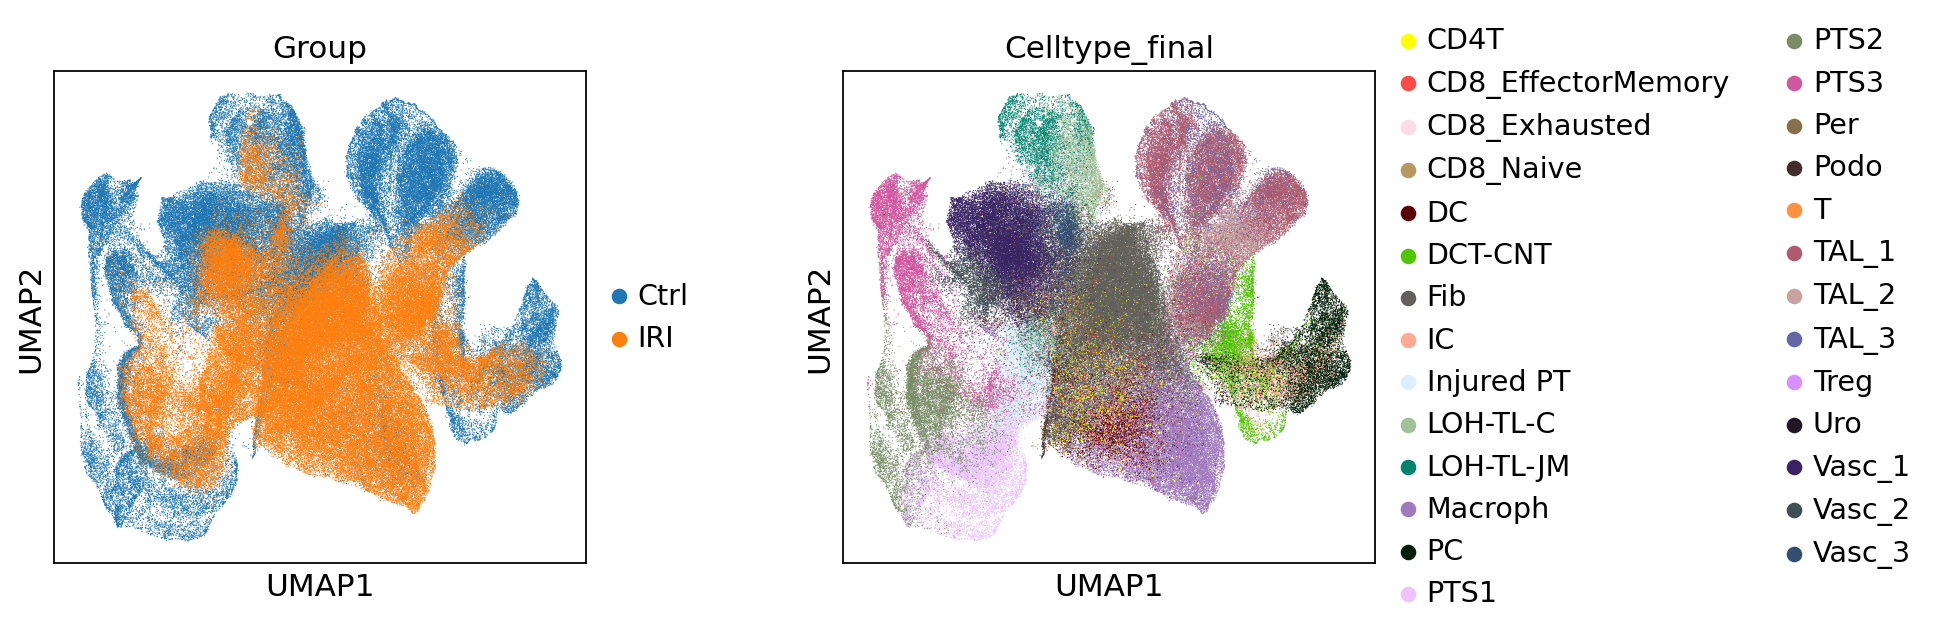

In [7]:
joint_umap_fig = sc.pl.umap(
    adata,
    color=["Group", "Celltype_final"],
    size=1,
    wspace=0.35,
    return_fig=True,
)

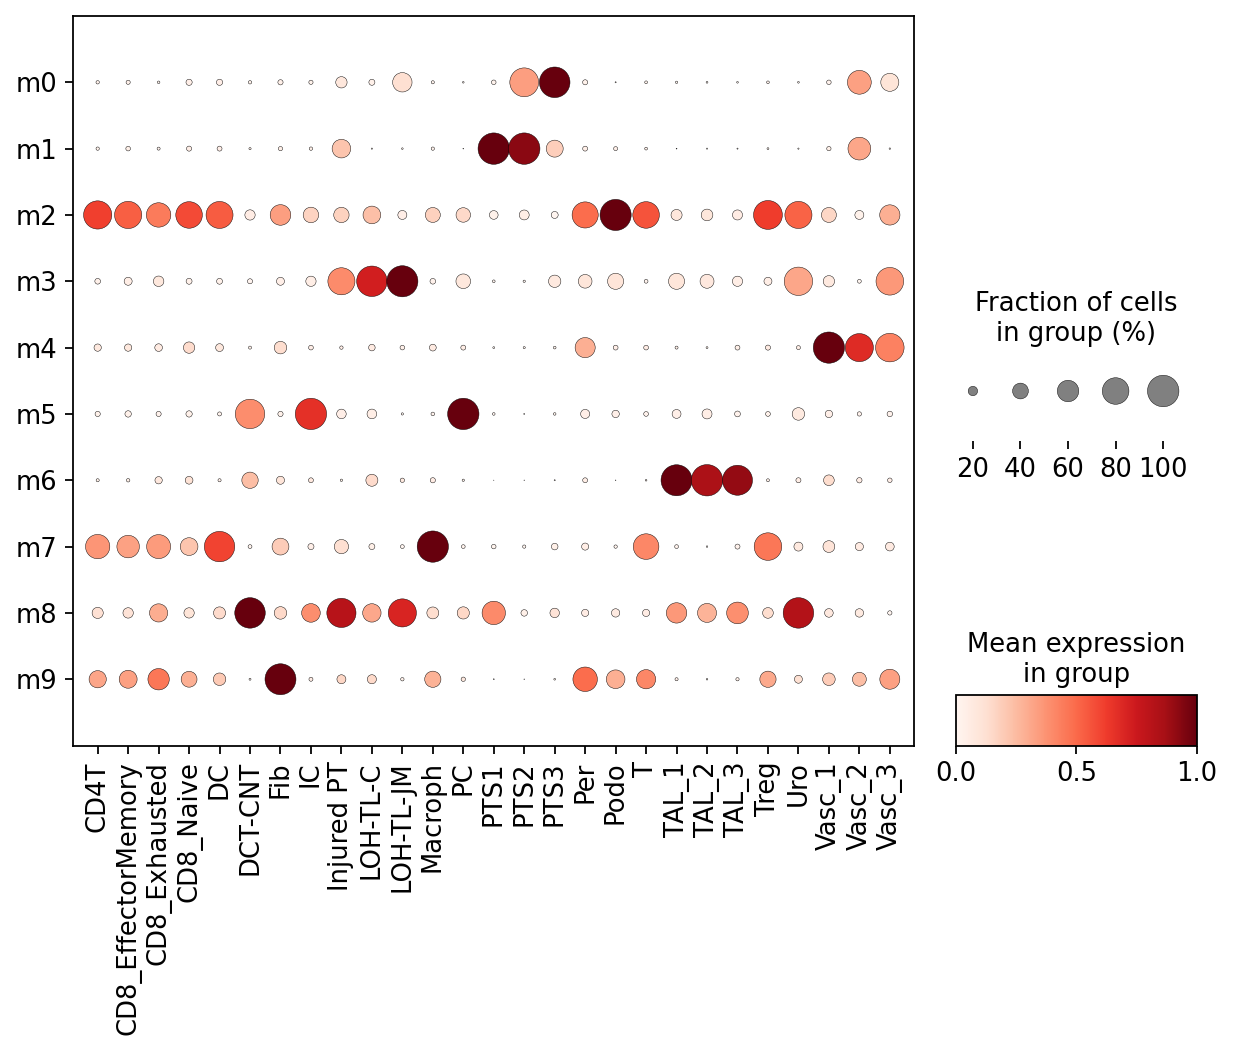

In [8]:
metagene_celltype_dotplot = pl.embedding_label_dotplot(
    adata,
    embedding_key="normalized_X",
    label_key="Celltype_final",
    figsize=(9, 6),
)

## Spatial cell types and metagenes

The supplied cell-type annotations provide an orthogonal reference for interpreting Popari's learned programs. The first metagene is shown as an example; select another index to inspect a different program.

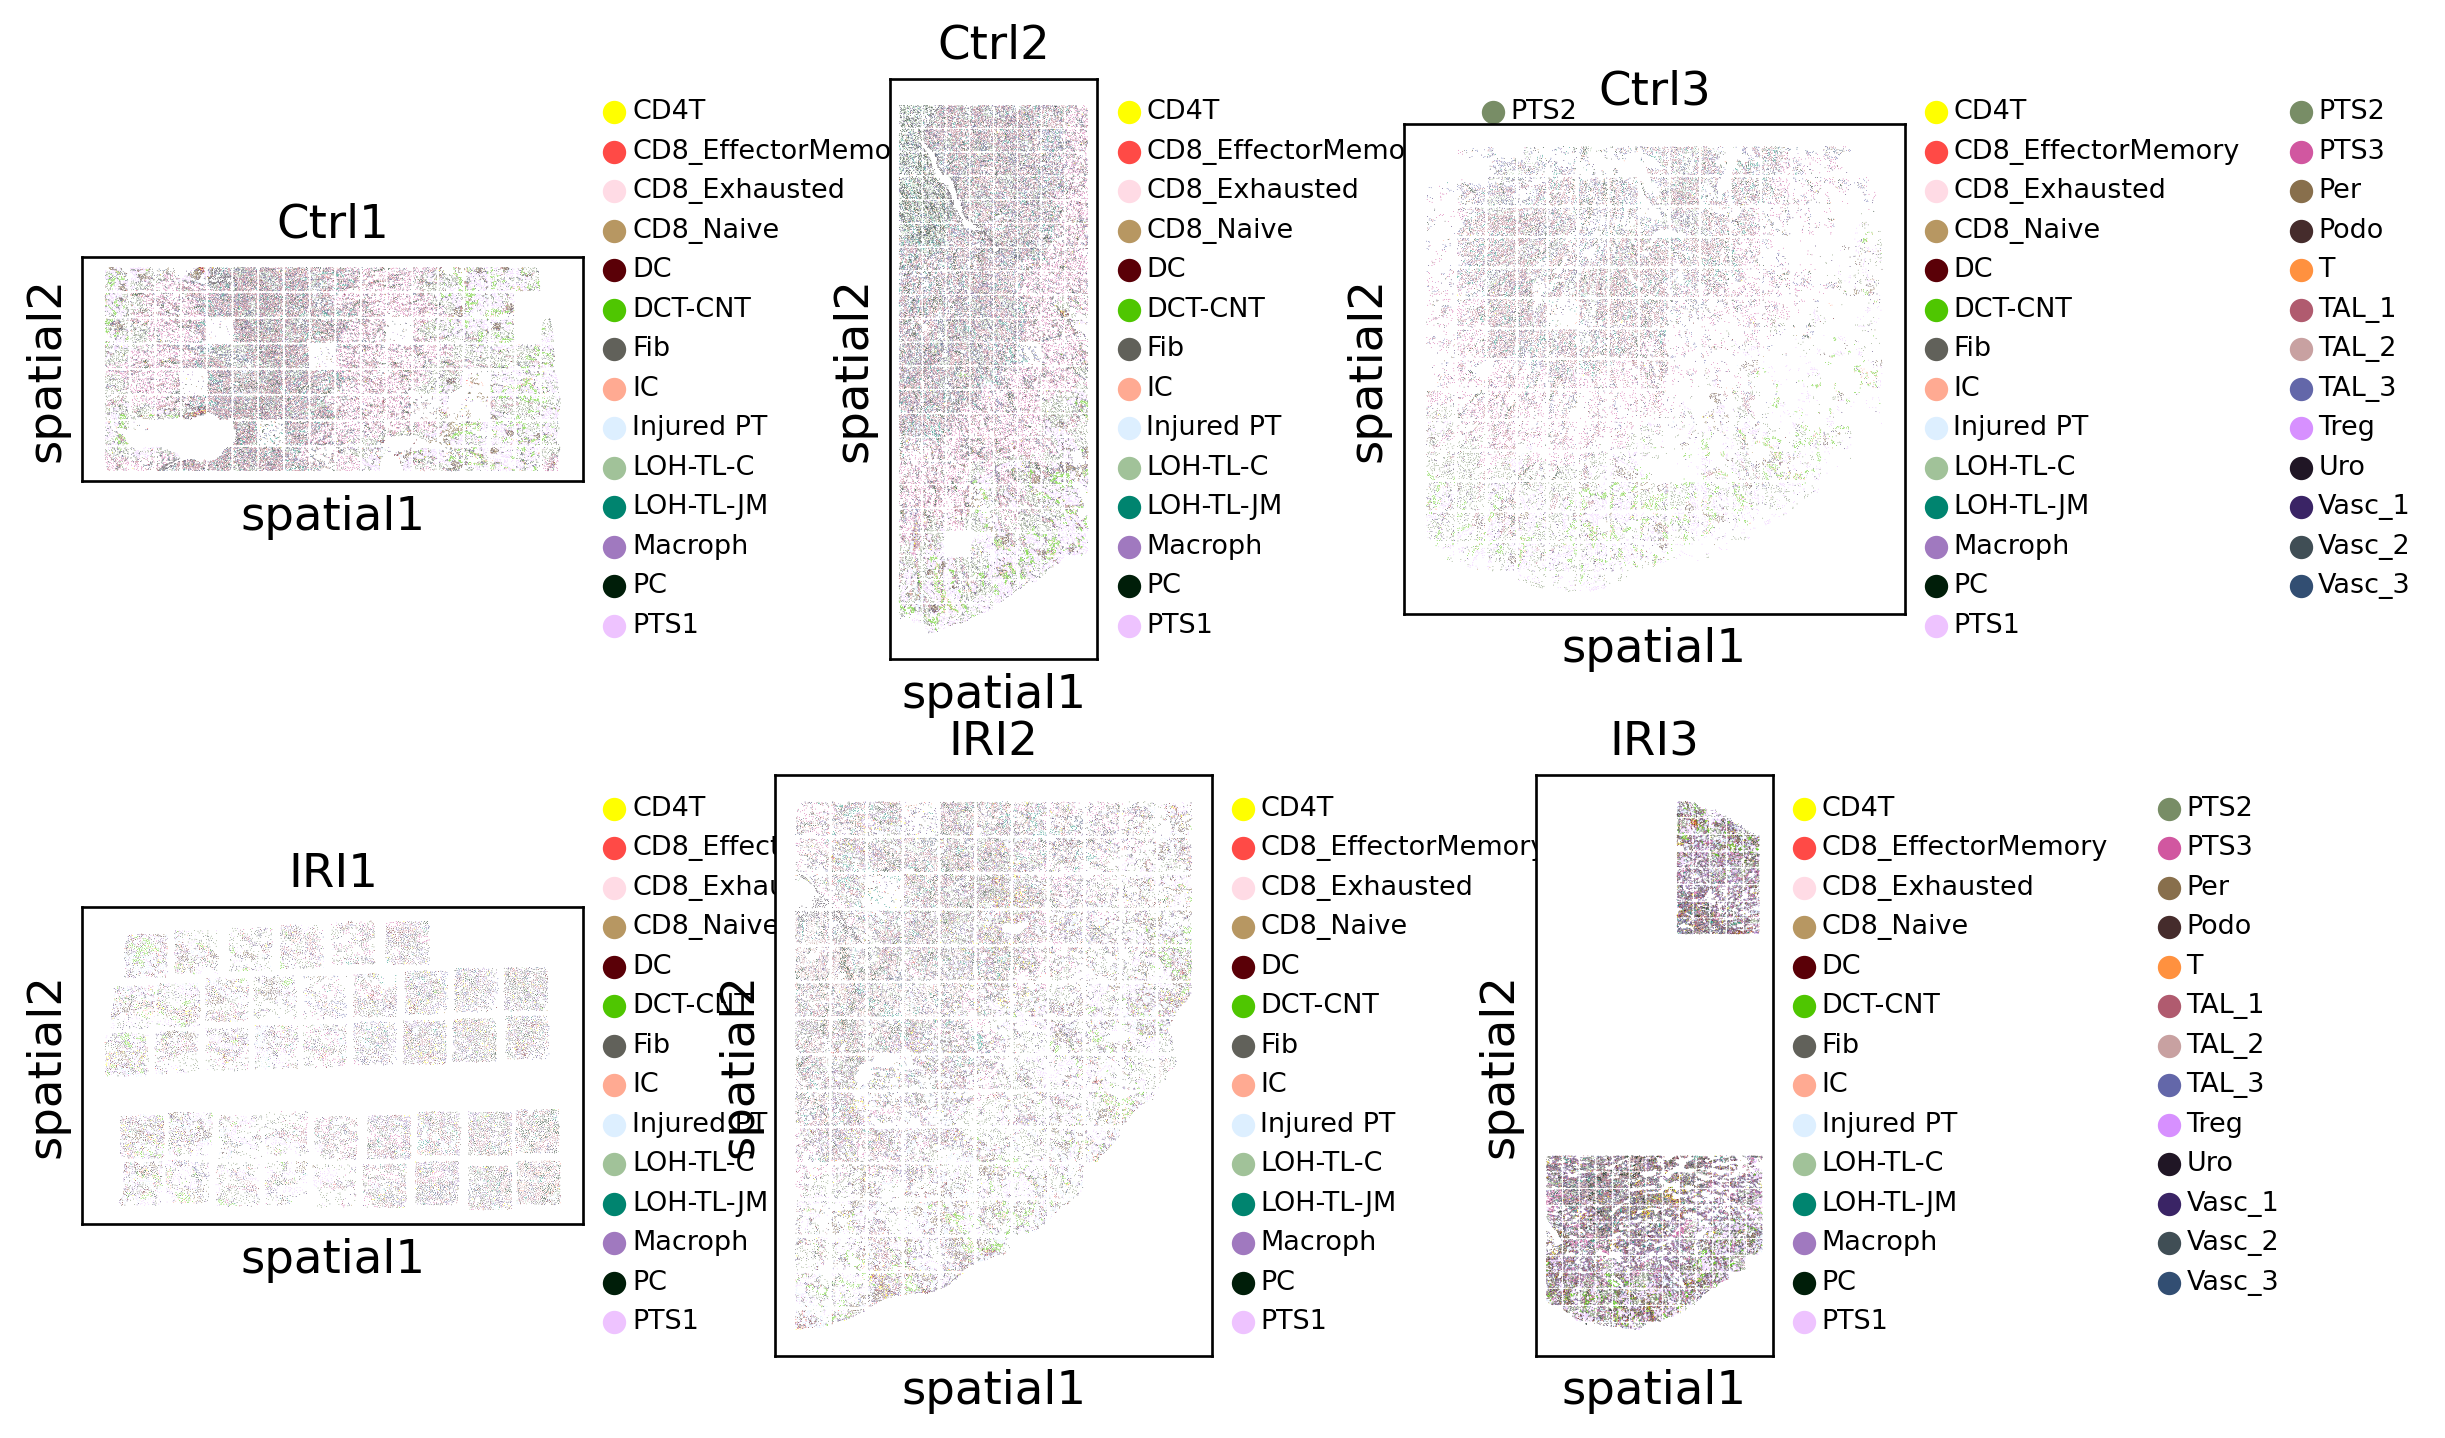

In [9]:
celltype_spatial_fig = pl.in_situ(
    adata,
    color="Celltype_final",
    edges_width=0,
    size=6,
    figsize=(10, 7),
    dpi=120,
)

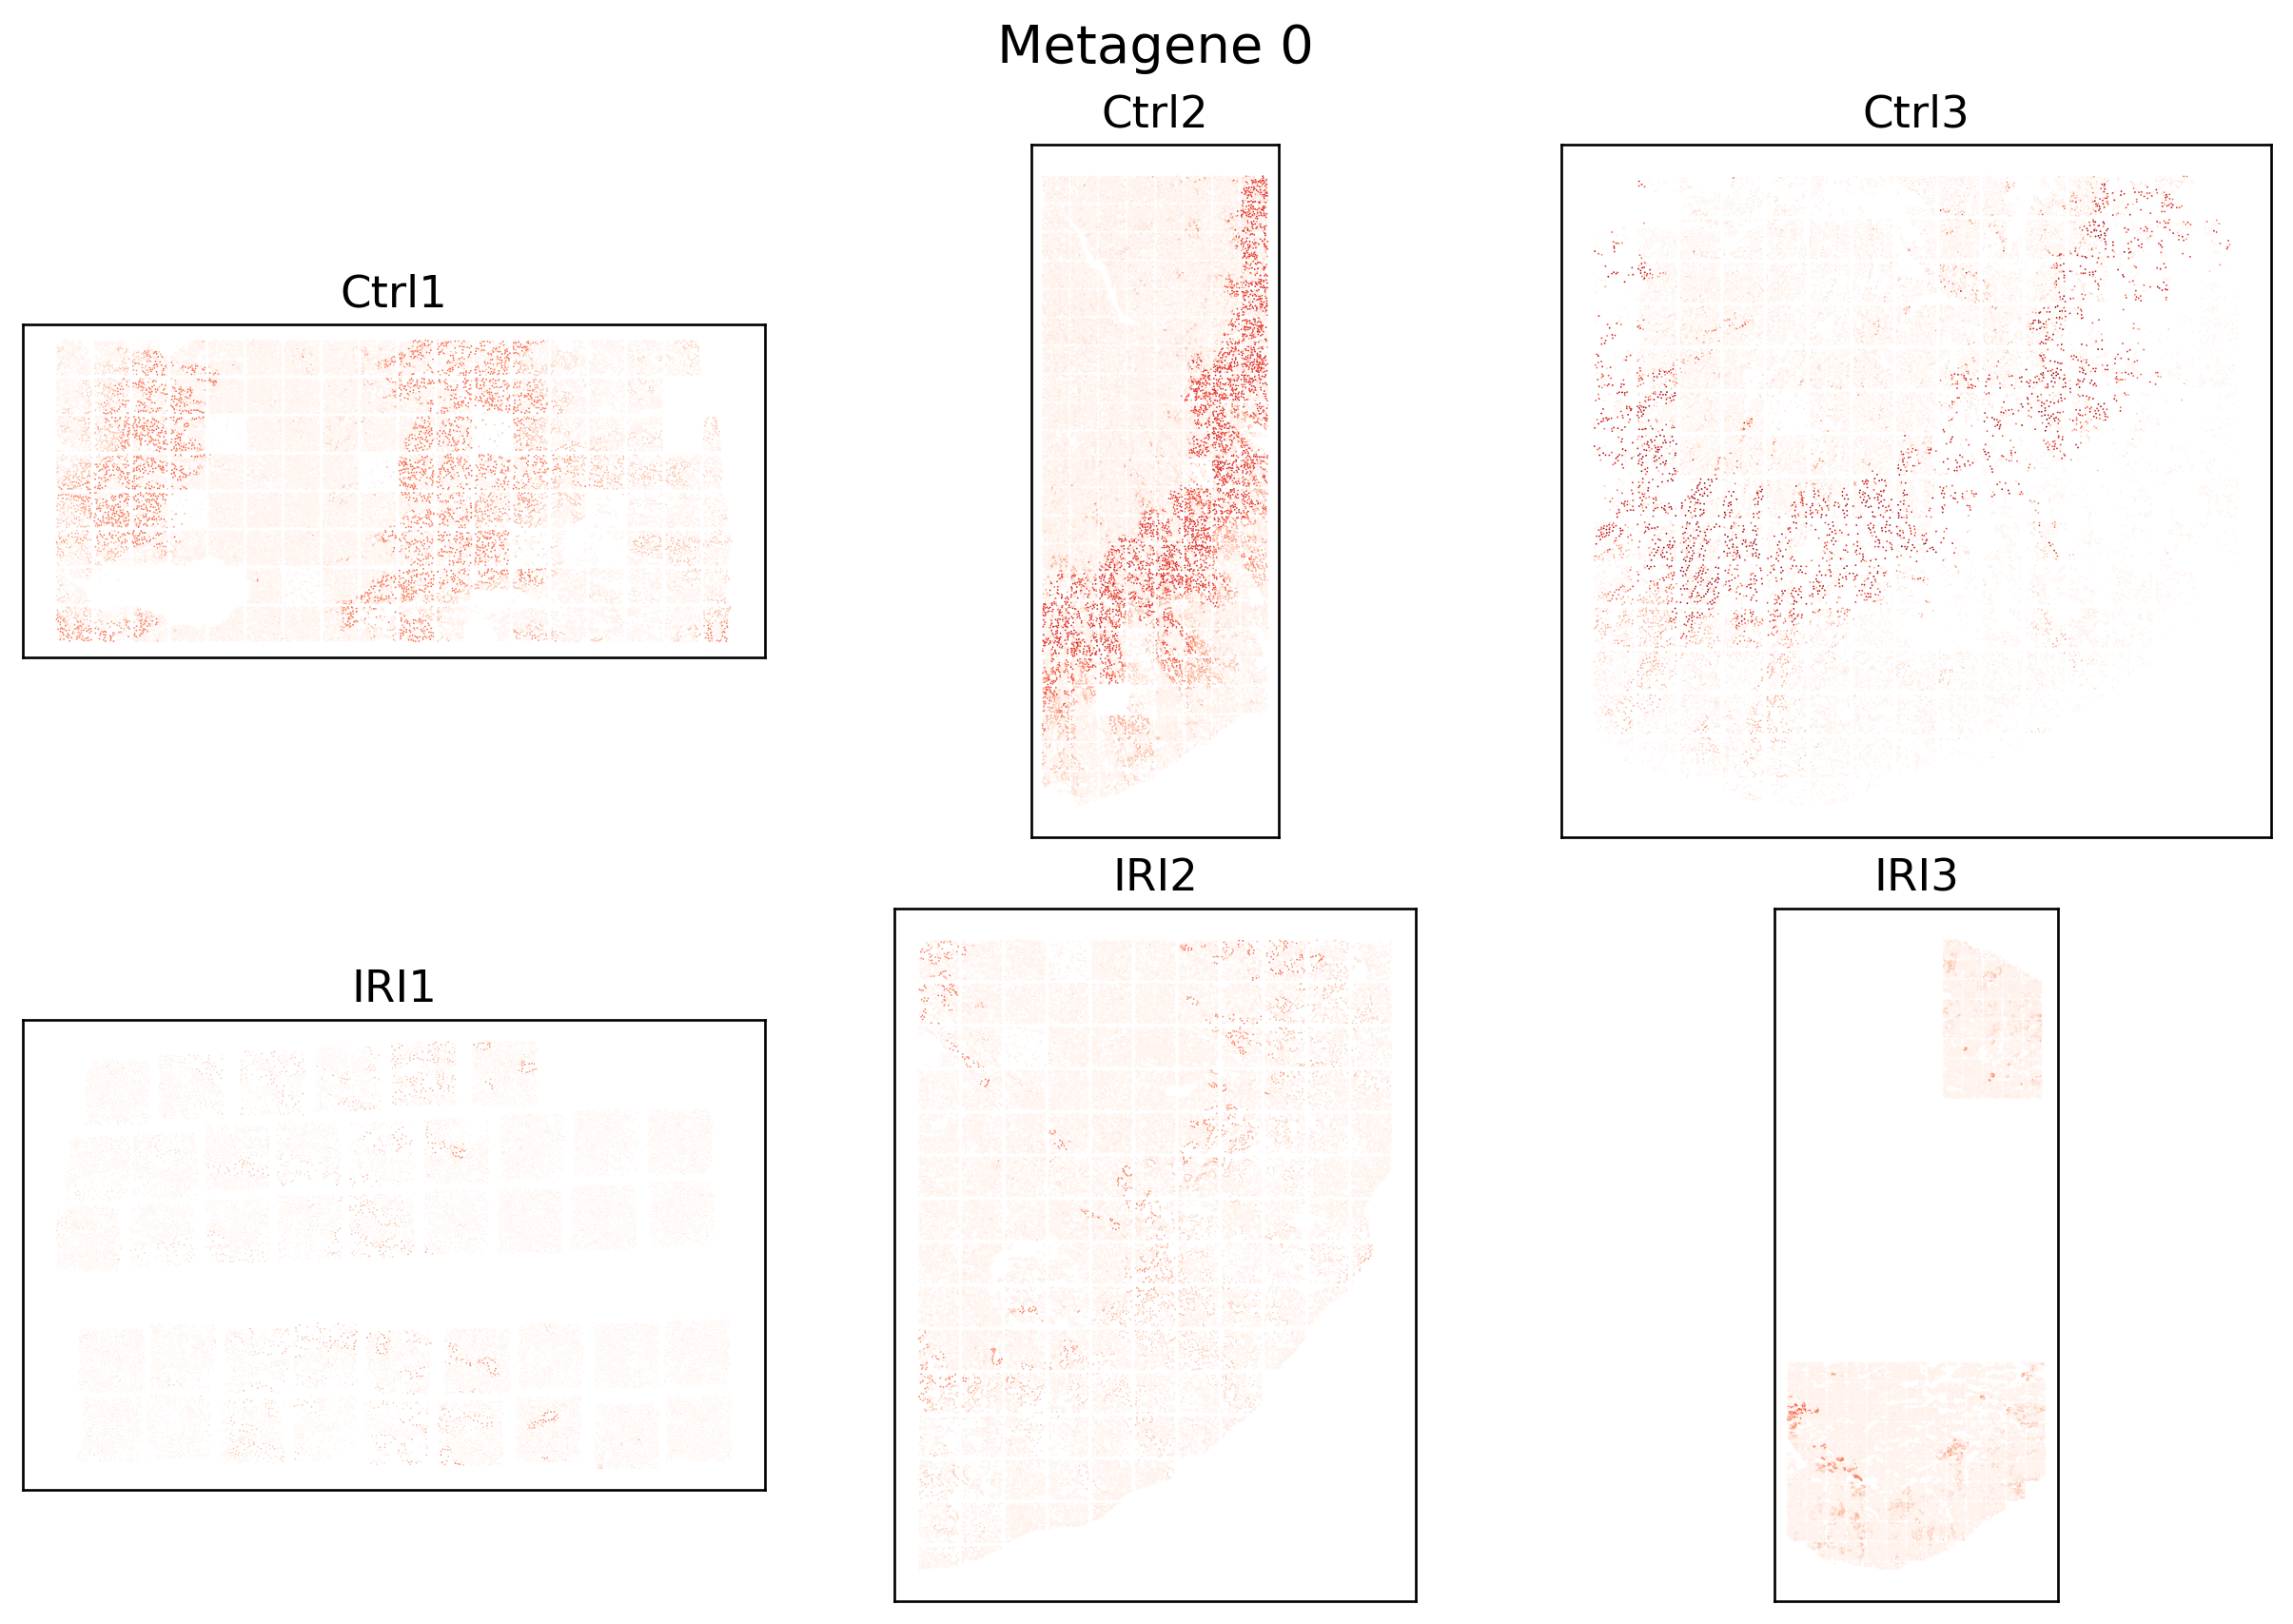

In [10]:
METAGENE = 0
metagene_spatial_fig = pl.metagene_embedding(
    adata,
    METAGENE,
    s=0.3,
    figsize=(10, 7),
    dpi=120,
    palette="Reds",
)

In [11]:
NUM_TOP_GENES = 20
metagenes = np.asarray(adata.uns["M"])
top_gene_indices = np.argsort(metagenes[:, METAGENE])[-NUM_TOP_GENES:][::-1]
pd.DataFrame(
    {
        "gene": adata.var_names[top_gene_indices],
        "weight": metagenes[top_gene_indices, METAGENE],
    }
)

,gene,weight
0,Acsm3,0.039988
1,Aqp1,0.036675
2,Slc7a13,0.033116
3,Napsa,0.031964
4,Gclc,0.029373
5,Acsm2,0.029133
6,Ehhadh,0.027561
7,Cyp7b1,0.026638
8,Pck1,0.022837
9,Ghr,0.021212


## Healthy and injured spatial affinities

The saved run defines healthy and injured sample groups. We average the sample-specific affinity matrices within each group, then visualize the injured-minus-healthy contrast.

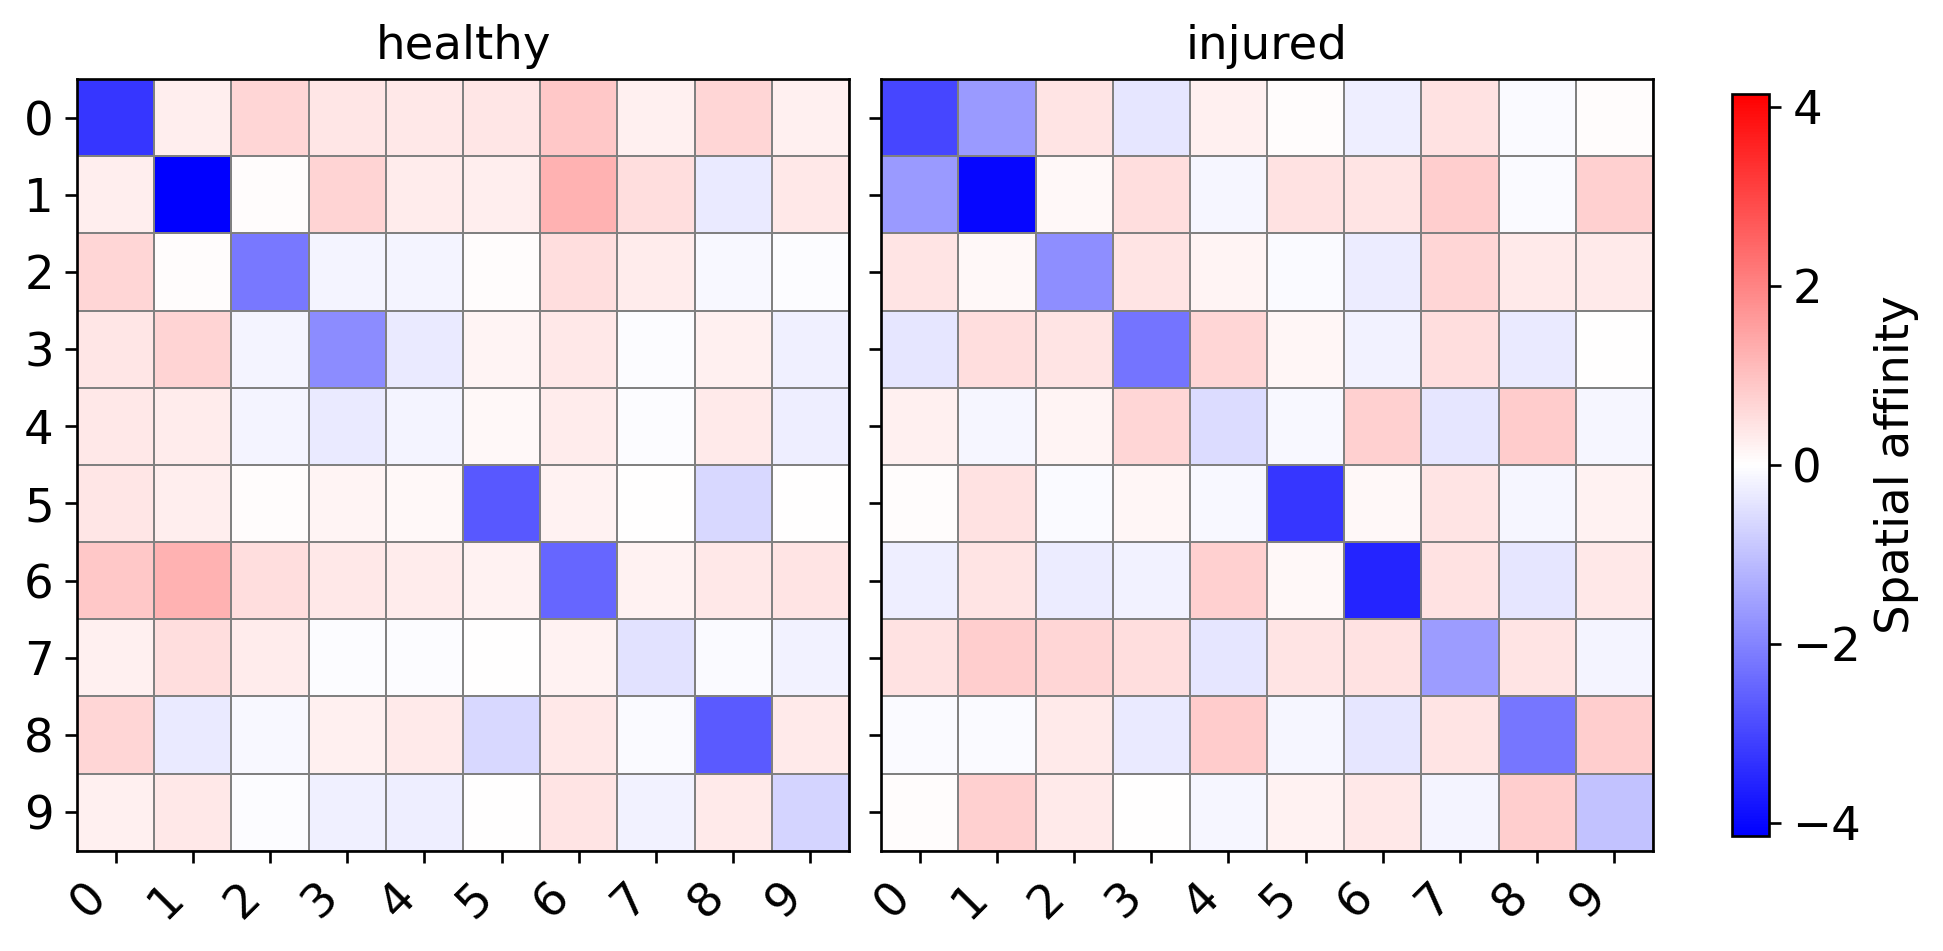

In [12]:
COHORTS = {
    cohort: list(samples)
    for cohort, samples in hyperparameters["spatial_affinity_groups"].items()
}
adata.uns["cohort_Sigma_x_inv"] = tl.aggregate_sample_matrices(
    adata,
    COHORTS,
    "Sigma_x_inv",
)

cohort_affinity_fig = pl.matrix_heatmap_panel(
    adata.uns["cohort_Sigma_x_inv"],
    center_zero=True,
    shared_scale=True,
    colorbar="shared",
    colorbar_label="Spatial affinity",
    cmap="bwr",
    figsize=(8, 4),
    dpi=120,
)

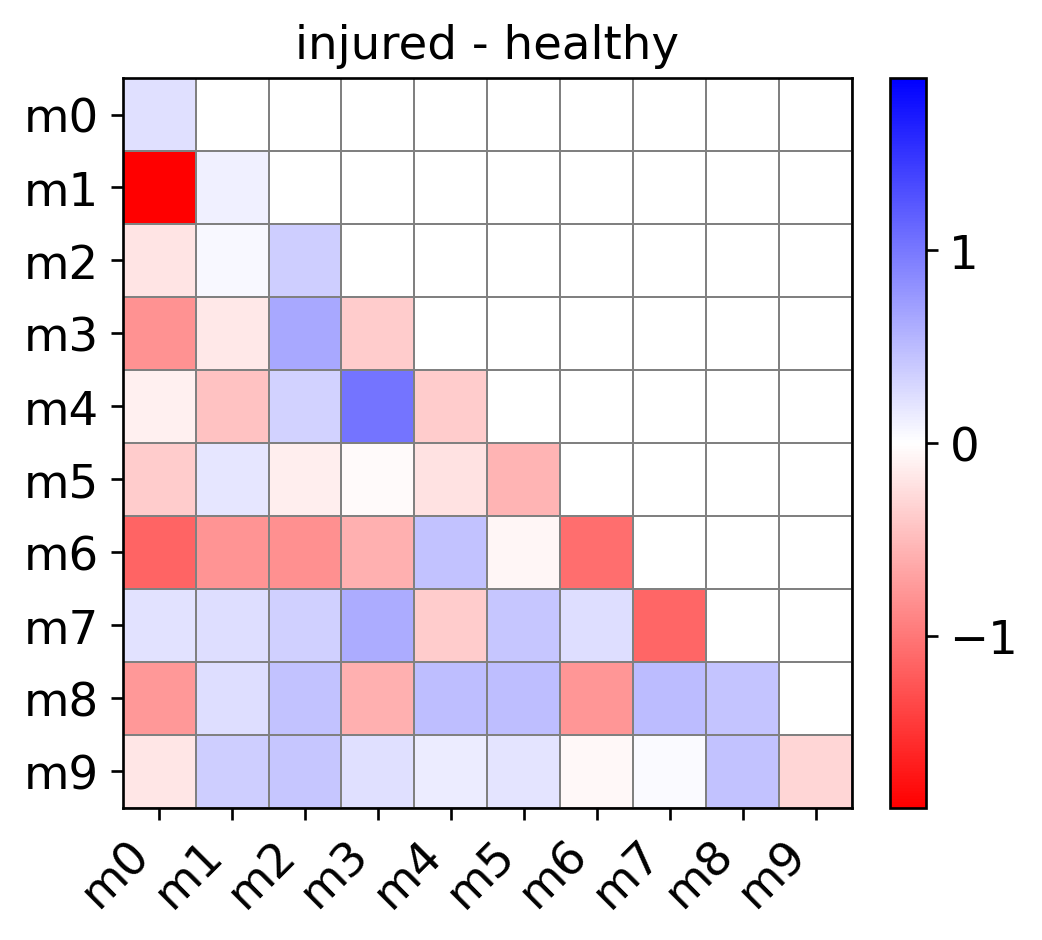

In [13]:
cohort_affinity_difference_fig = pl.affinity_difference(
    adata,
    comparison="injured",
    reference="healthy",
    spatial_affinity_key="cohort_Sigma_x_inv",
    figsize=(5, 4),
    dpi=120,
)

## Differential cell-type spatial accordance

Spatial accordance combines a learned affinity matrix with the metagene activity on spatial graph edges. Here, related T-cell annotations are pooled, rare cell-type pairs are masked, and cohort values are weighted by the number of observed edges.

In [14]:
CELL_TYPE_KEY = "accordance_cell_type"
T_CELL_TYPES = {
    "T", "CD4T", "CD8_Naive", "CD8_EffectorMemory", "CD8_Exhausted", "Treg"
}
adata.obs[CELL_TYPE_KEY] = (
    adata.obs["Celltype_final"]
    .astype(str)
    .replace({cell_type: "T cell" for cell_type in T_CELL_TYPES})
)

ACCORDANCE_CATEGORIES = [
    "PTS1", "PTS2", "PTS3", "Injured PT", "TAL_1", "DCT-CNT",
    "Vasc_1", "Vasc_2", "Fib", "Per", "Macroph", "DC", "T cell",
]
MIN_EDGES = 100

In [15]:
accordance_by_sample = {}
accordance_counts_by_sample = {}
for sample in adata.popari.sample_names:
    interactions = tl.compute_edge_interactions(adata, sample=sample)
    labels = adata.obs.loc[interactions.obs_names, CELL_TYPE_KEY]
    scores, counts = interactions.category_summary(
        labels,
        categories=ACCORDANCE_CATEGORIES,
    )
    accordance_by_sample[sample] = scores
    accordance_counts_by_sample[sample] = counts


def aggregate_accordance(samples):
    counts = sum(accordance_counts_by_sample[sample] for sample in samples)
    weighted_scores = sum(
        accordance_by_sample[sample] * accordance_counts_by_sample[sample]
        for sample in samples
    )
    return weighted_scores.divide(counts).where(counts > 0), counts


cohort_accordance = {}
cohort_accordance_counts = {}
for cohort, samples in COHORTS.items():
    cohort_accordance[cohort], cohort_accordance_counts[cohort] = aggregate_accordance(samples)

supported_pairs = (
    (cohort_accordance_counts["healthy"] >= MIN_EDGES)
    & (cohort_accordance_counts["injured"] >= MIN_EDGES)
)
accordance_difference = (
    cohort_accordance["injured"] - cohort_accordance["healthy"]
).where(supported_pairs)

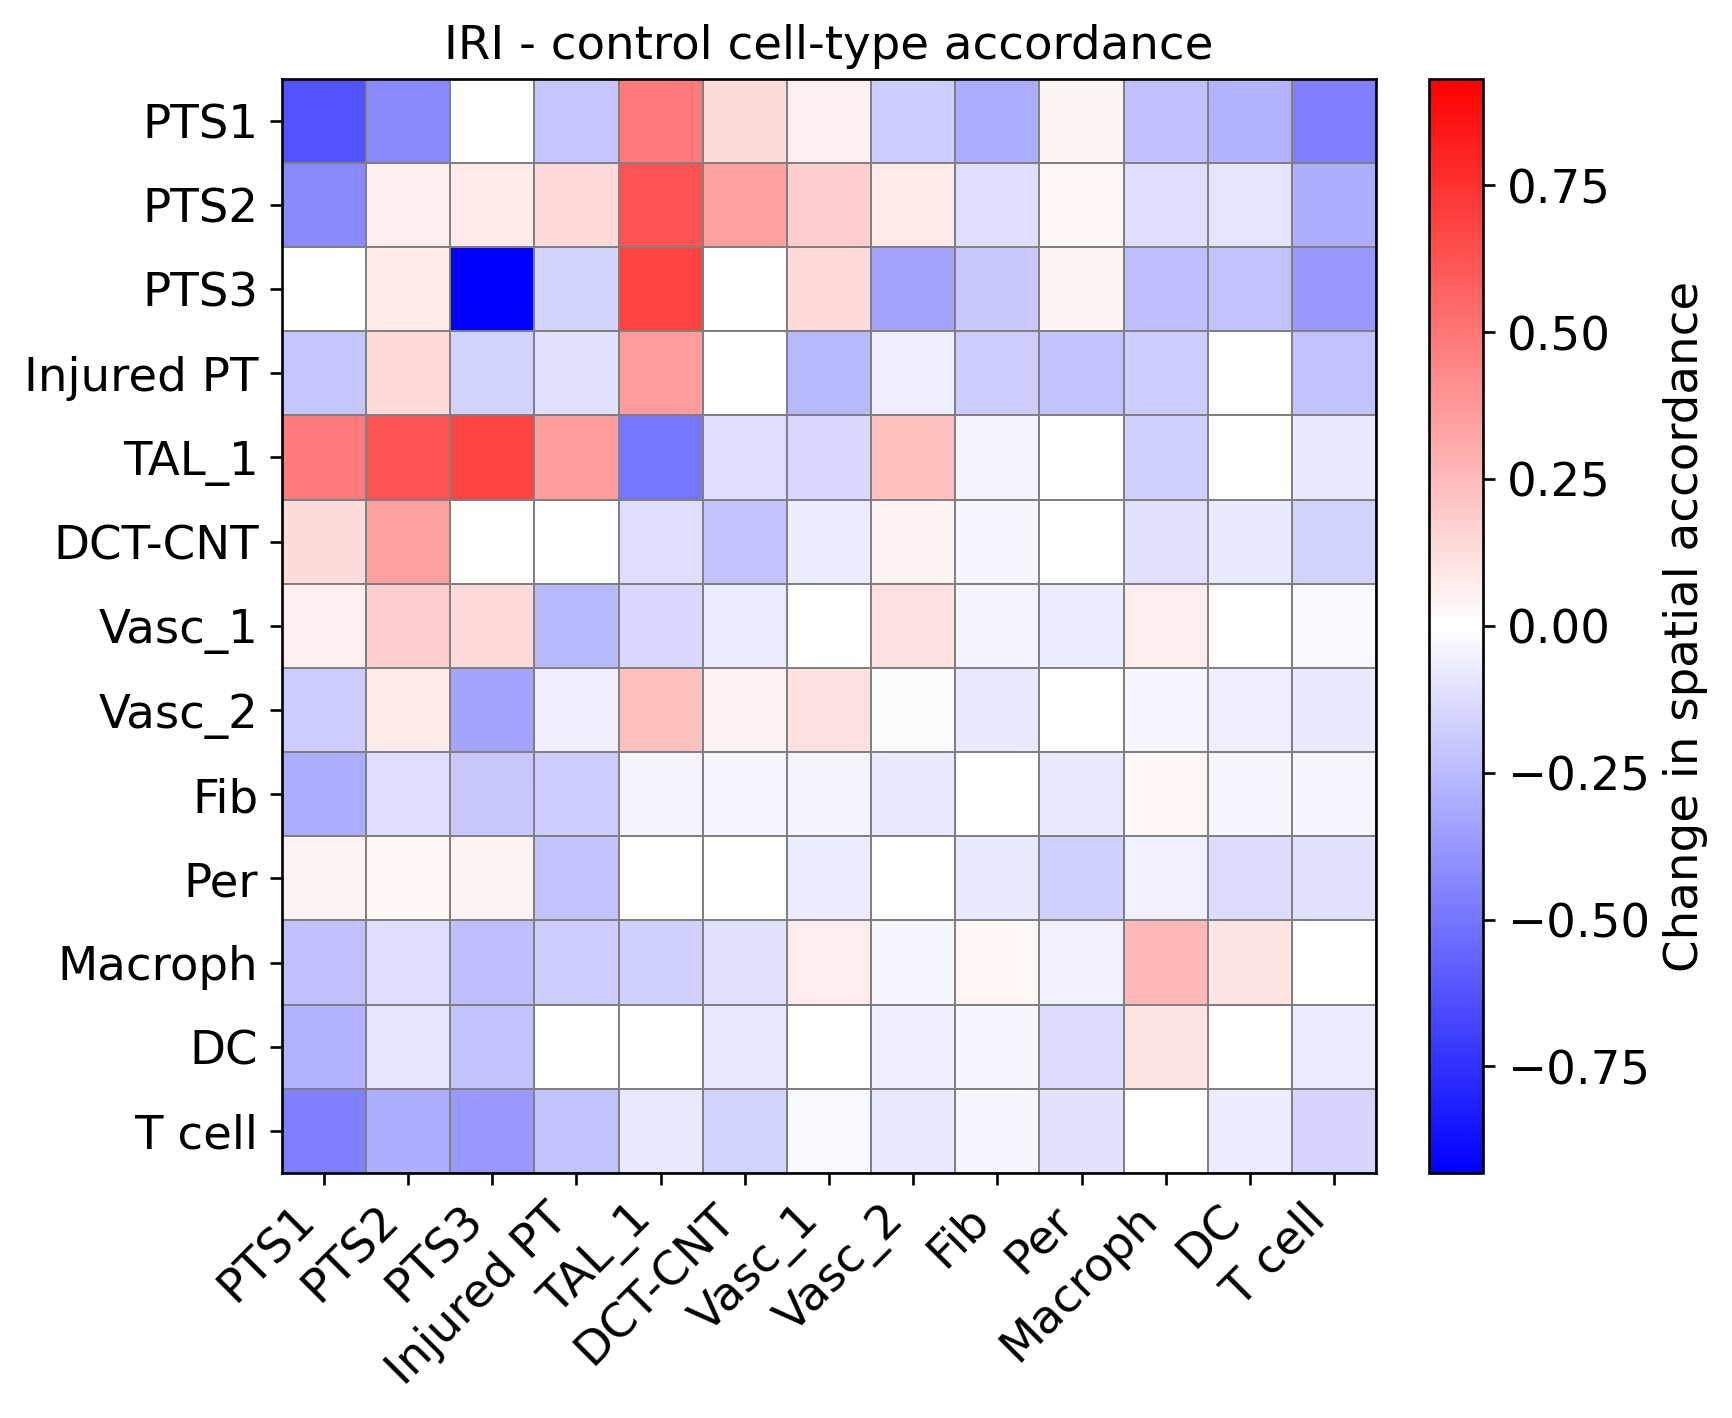

In [16]:
accordance_difference_fig = pl.matrix_heatmap(
    accordance_difference,
    title="IRI - control cell-type accordance",
    cmap="bwr",
    center_zero=True,
    colorbar_label="Change in spatial accordance",
    figsize=(7, 6),
    dpi=120,
)

### Model-independent neighbor frequencies

Changes in raw category-to-category edge frequencies provide a model-independent comparison. This helps distinguish altered tissue composition or adjacency from changes emphasized by the learned affinity contrast.

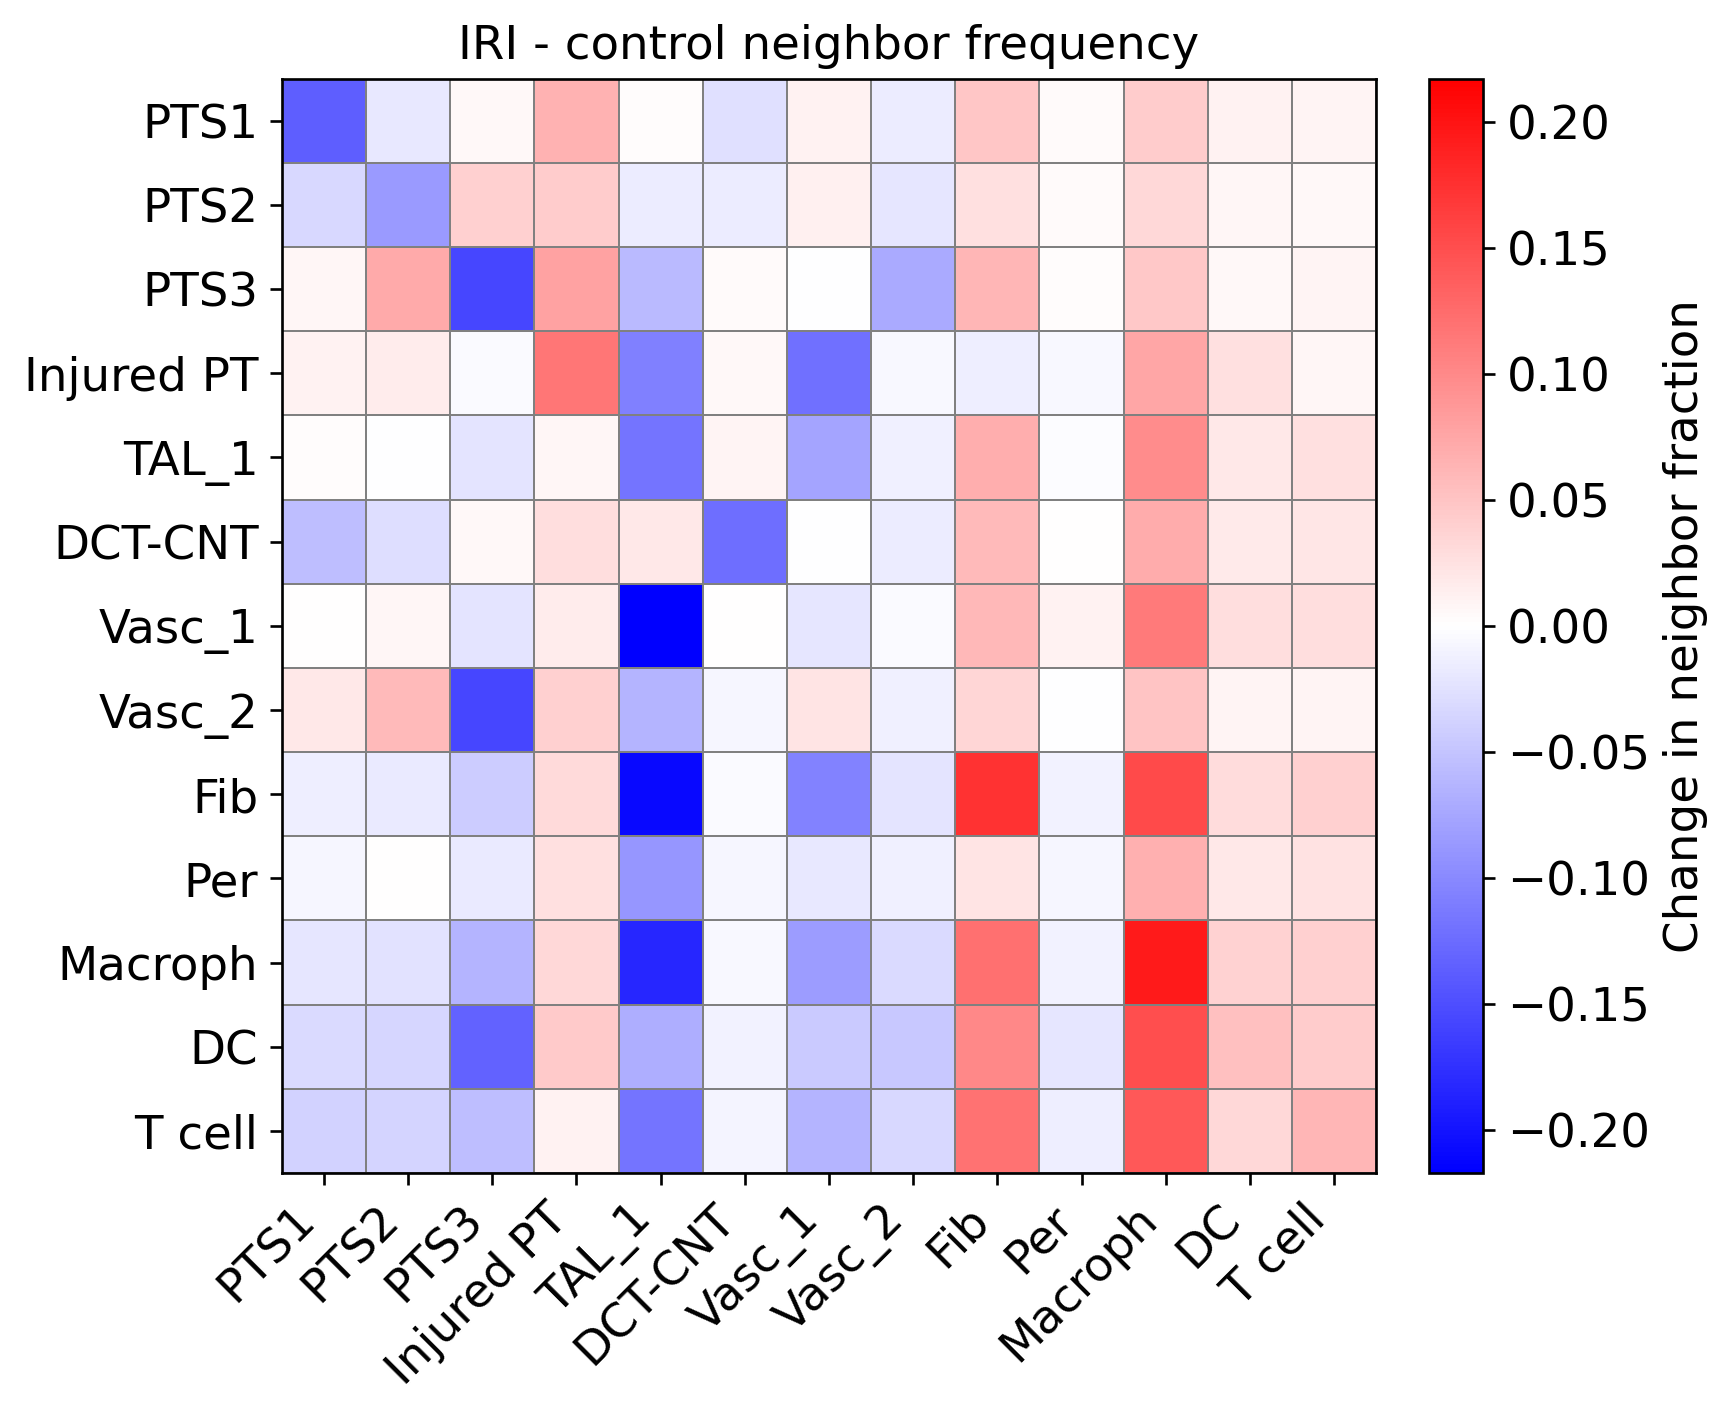

In [17]:
neighbor_rates_by_sample = {
    sample: tl.compute_category_edge_rates(
        adata,
        categories=ACCORDANCE_CATEGORIES,
        sample=sample,
        category_key=CELL_TYPE_KEY,
    )
    for sample in adata.popari.sample_names
}
cohort_neighbor_rates = {
    cohort: sum(neighbor_rates_by_sample[sample] for sample in samples) / len(samples)
    for cohort, samples in COHORTS.items()
}
neighbor_rate_difference = (
    cohort_neighbor_rates["injured"] - cohort_neighbor_rates["healthy"]
)
neighbor_rate_difference_fig = pl.matrix_heatmap(
    neighbor_rate_difference,
    title="IRI - control neighbor frequency",
    cmap="bwr",
    center_zero=True,
    colorbar_label="Change in neighbor fraction",
    figsize=(7, 6),
    dpi=120,
)

### Localize the learned contrast

Finally, apply the same injured-minus-healthy affinity contrast to one representative sample from each cohort. Edge colors show where the learned differential accordance is expressed in the tissue.

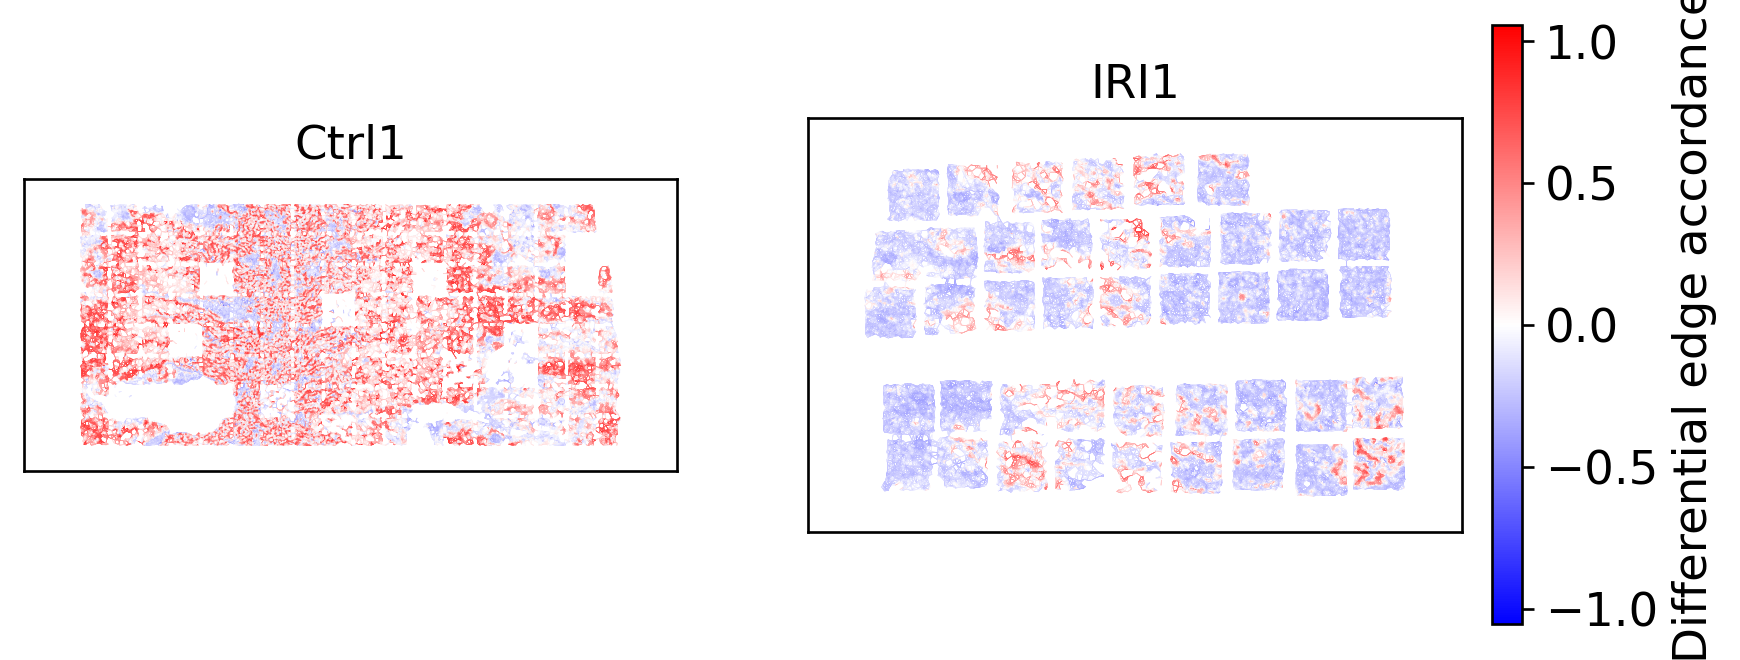

In [18]:
representative_samples = [COHORTS["healthy"][0], COHORTS["injured"][0]]
differential_interactions = {
    sample: tl.compute_differential_edge_interactions(
        adata,
        comparison="injured",
        reference="healthy",
        sample=sample,
        affinity_key="cohort_Sigma_x_inv",
    )
    for sample in representative_samples
}

differential_edge_accordance_fig = pl.edge_interactions_panel(
    adata,
    differential_interactions,
    samples=representative_samples,
    score="total",
    color=None,
    edge_cmap="bwr",
    center_zero=True,
    edges_width=0.15,
    size=0,
    figsize=(8, 4),
    dpi=120,
    colorbar_label="Differential edge accordance",
)